# Ego4D - Object Detection

Problem 1: Given a frame from an egocentric video, detect the target object in the vision query

e.g
-  "Target object": "Mr krips jar"
- Clip provided: Egocentric view of a person shopping in a grocery aisle


## Models
| Model | Architecture | Pretrained On |
|-------|-------------|---------------|
| YOLOv8s | Anchor-free, multi-scale CNN | COCO |
| Deformable DETR | Transformer + deformable attention | COCO |


**Evaluation protocol**
- Zero-shot: pretrained COCO weights, all predictions treated as class-agnostic

- Fine-tuned: trained on eGO4d response track frames

- Metrics: mAP@0.5, mAP@0.5:0.95

**Key findings from EDA informing the object detection problem formulation**

1. Median normalized object area within a frame: 1.9% of the frame

2. Frame resolution: 720 x 540 - 2x downsclaed from annotation space

3. 246,206 labeled detection frames across train and validation splits

4. Single class (object-agnostic detection) - Class-agnostic object detection (CA-OD) is a computer vision approach that localizes all objects within an image by drawing bounding boxes without identifying their specific categories (e.g., detecting "an object" rather than "a car" or "a dog"). This method improves generalization to unseen objects, reduces dependence on fully labeled datasets, and powers open-world detection

## Imports & Configurations

In [70]:
!pip install ultralytics transformers torch torchvision google-cloud-storage pycocotools tqdm --quiet

In [71]:
import json
import os
import random
import io
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from tqdm import tqdm
from google.cloud import storage
from transformers import AutoImageProcessor, DeformableDetrForObjectDetection
from PIL import Image
import subprocess

In [72]:
#GCS configuration
BUCKET_NAME = "egorecall-data"

#Local paths
DATA_DIR = Path("/content/egorecall_detection")
RESULTS_DIR = Path("/content/results/detection")

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [73]:
# Training configurations
DETR_MODEL    = "SenseTime/deformable-detr"
NUM_CLASSES   = 1
BATCH_SIZE    = 2
EPOCHS        = 5
LR            = 1e-5
RANDOM_SEED   = 42

# Subset config — full dataset is too large for DETR per epoch
N_TRAIN_CLIPS = 100   # ~200 clips × ~90 frames = ~18K train frames
N_VAL_CLIPS   = 50    # ~50 clips × ~90 frames = ~4.5K val frames

In [74]:
CHECKPOINT_PATH = RESULTS_DIR / "detr_checkpoint.json"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## GCS Authentication

In [75]:
from google.colab import auth
auth.authenticate_user()

gcs_client = storage.Client()
bucket = gcs_client.bucket(BUCKET_NAME)
print(f"Connected to gs://{BUCKET_NAME}")

Connected to gs://egorecall-data


## Sync Detection Frames from GCS to Local Colab

Estimated size is 19GB, which fits comfortably within Colab Pro's 200GB disk

In [76]:
result = subprocess.run(["df", "-h", "/content"], capture_output=True, text=True)
print(result.stdout)

Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   91G  145G  39% /



In [77]:
# Create directories first
(DATA_DIR / "train" / "images").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "val"   / "images").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "train" / "labels").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "val"   / "labels").mkdir(parents=True, exist_ok=True)
print("Directories created.")

Directories created.


In [78]:
!gsutil cp gs://egorecall-data/processed/lbl_val.tar.gz   /tmp/
!tar -xzf /tmp/lbl_val.tar.gz   -C /content/egorecall_detection/val/labels/   --strip-components=2

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://egorecall-data/processed/lbl_val.tar.gz...
/ [1 files][  2.1 MiB/  2.1 MiB]                                                
Operation completed over 1 objects/2.1 MiB.                                      


In [79]:
!gsutil cp gs://egorecall-data/processed/det_val.tar.gz   /tmp/
!tar -xzf /tmp/det_val.tar.gz   -C /content/egorecall_detection/val/images/   --strip-components=2

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://egorecall-data/processed/det_val.tar.gz...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

/ [1 files][  5.0 GiB/  5.0 GiB]  172.6 MiB/s                                   
Operation completed over 1 objects/5.0 GiB.                                      


In [80]:
!gsutil cp gs://egorecall-data/processed/lbl_train.tar /tmp/
!tar -xf /tmp/lbl_train.tar -C /content/egorecall_detection/train/labels/ --strip-components=2

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://egorecall-data/processed/lbl_train.tar...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

\
Operation completed over 1 objects/181.7 MiB.                                    


In [81]:
!gsutil cp gs://egorecall-data/processed/det_train.tar /tmp/
!tar -xf /tmp/det_train.tar -C /content/egorecall_detection/train/images/ --strip-components=2

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://egorecall-data/processed/det_train.tar...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

\ [1 files][ 14.9 GiB/ 14.9 GiB]  196.9 MiB/s                                   
Operation completed over 1 objects/14.9 GiB.                                     


In [82]:
# Verify
train_imgs   = list((DATA_DIR / "train" / "images").rglob("*.jpg"))
val_imgs     = list((DATA_DIR / "val"   / "images").rglob("*.jpg"))
train_labels = list((DATA_DIR / "train" / "labels").rglob("*.txt"))
val_labels   = list((DATA_DIR / "val"   / "labels").rglob("*.txt"))

print(f"\nTrain images : {len(train_imgs):,}")
print(f"Train labels : {len(train_labels):,}")
print(f"Val images   : {len(val_imgs):,}")
print(f"Val labels   : {len(val_labels):,}")


Train images : 184,332
Train labels : 184,332
Val images   : 61,874
Val labels   : 61,874


### Flatten Structure

In [83]:
import shutil

shutil.rmtree(DATA_DIR / "train" / "images_flat", ignore_errors=True)
shutil.rmtree(DATA_DIR / "train" / "labels_flat", ignore_errors=True)
shutil.rmtree(DATA_DIR / "val"   / "images_flat", ignore_errors=True)
shutil.rmtree(DATA_DIR / "val"   / "labels_flat", ignore_errors=True)
print("Cleaned up old symlinks.")

Cleaned up old symlinks.


In [84]:
def flatten_split(split):
    img_dir  = DATA_DIR / split / "images" / f"det_{split}"   # det_train or det_val
    lbl_dir  = DATA_DIR / split / "labels" / f"lbl_{split}"   # lbl_train or lbl_val
    flat_img = DATA_DIR / split / "images_flat"
    flat_lbl = DATA_DIR / split / "labels_flat"
    flat_img.mkdir(exist_ok=True)
    flat_lbl.mkdir(exist_ok=True)

    imgs = list(img_dir.rglob("*.jpg"))
    for img_path in tqdm(imgs, desc=f"Flattening {split}"):
        clip_uid = img_path.parent.name
        new_name = f"{clip_uid}_{img_path.name}"

        # Symlink image
        dst_img = flat_img / new_name
        if not dst_img.exists():
            dst_img.symlink_to(img_path.resolve())

        # Label — use original frame stem without clip_uid prefix
        lbl_path = lbl_dir / clip_uid / img_path.stem
        lbl_path = lbl_path.with_suffix(".txt")
        dst_lbl  = flat_lbl / f"{clip_uid}_{img_path.stem}.txt"
        if lbl_path.exists() and not dst_lbl.exists():
            dst_lbl.symlink_to(lbl_path.resolve())

    return len(imgs)

n_train = flatten_split("train")
n_val   = flatten_split("val")
print(f"Flattened: {n_train:,} train, {n_val:,} val")

flat_imgs = list((DATA_DIR / "train" / "images_flat").glob("*.jpg"))
flat_lbls = list((DATA_DIR / "train" / "labels_flat").glob("*.txt"))
print(f"Train Flat images : {len(flat_imgs):,}")
print(f"Train Flat labels : {len(flat_lbls):,}")

Flattening val: 100%|██████████| 61874/61874 [00:15<00:00, 3894.61it/s]


Flattened: 184,332 train, 61,874 val
Train Flat images : 184,332
Train Flat labels : 184,332


In [85]:
flat_imgs = list((DATA_DIR / "val" / "images_flat").glob("*.jpg"))
flat_lbls = list((DATA_DIR / "val" / "labels_flat").glob("*.txt"))
print(f"Val Flat images : {len(flat_imgs):,}")
print(f"Val Flat labels : {len(flat_lbls):,}")

Val Flat images : 61,874
Val Flat labels : 61,874


## DETR - Data Subset

In [86]:
flat_train = DATA_DIR / "train" / "images_flat"
flat_val   = DATA_DIR / "val"   / "images_flat"

In [87]:
# Delete the bad subset file from GCS
try:
    bucket.blob("processed/detr_subset_clips.json").delete()
    print("Deleted old subset from GCS.")
except Exception:
    print("No existing subset to delete.")

# Now rebuild from scratch
random.seed(RANDOM_SEED)

flat_train = DATA_DIR / "train" / "images_flat"
flat_val   = DATA_DIR / "val"   / "images_flat"

all_train_clips = list(set(
    p.stem.rsplit("_", 1)[0]
    for p in flat_train.glob("*.jpg")
))
all_val_clips = list(set(
    p.stem.rsplit("_", 1)[0]
    for p in flat_val.glob("*.jpg")
))

print(f"Unique train clips found : {len(all_train_clips)}")
print(f"Unique val clips found   : {len(all_val_clips)}")

subset_train_clips = random.sample(all_train_clips, min(N_TRAIN_CLIPS, len(all_train_clips)))
subset_val_clips   = random.sample(all_val_clips,   min(N_VAL_CLIPS,   len(all_val_clips)))

print(f"Subset train clips : {len(subset_train_clips)}")
print(f"Subset val clips   : {len(subset_val_clips)}")

No existing subset to delete.
Unique train clips found : 3533
Unique val clips found   : 1157
Subset train clips : 100
Subset val clips   : 50


In [88]:
class EgoRecallDataset(Dataset):
    def __init__(self, img_dir, lbl_dir, clip_list, processor):
        self.samples   = []
        self.processor = processor
        clip_set       = set(clip_list)

        for img_path in sorted(img_dir.glob("*.jpg")):
            clip_uid = img_path.stem.rsplit("_", 1)[0]
            if clip_uid not in clip_set:
                continue
            # Look for label in lbl_dir
            lbl_path = lbl_dir / img_path.with_suffix(".txt").name
            if lbl_path.exists():
                self.samples.append((img_path, lbl_path))

        print(f"  Dataset: {len(self.samples):,} samples from {len(clip_list)} clips")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, lbl_path = self.samples[idx]
        img  = Image.open(img_path).convert("RGB")
        w, h = img.size

        boxes, labels = [], []
        for line in lbl_path.read_text().strip().split("\n"):
            if not line.strip(): continue
            _, cx, cy, bw, bh = map(float, line.split())
            boxes.append([cx, cy, bw, bh])
            labels.append(0)

        if not boxes:
            boxes  = [[0.5, 0.5, 0.1, 0.1]]
            labels = [0]

        target = {
            "image_id": idx,
            "annotations": [
                {
                    "bbox"       : [cx, cy, bw, bh],
                    "category_id": 0,
                    "area"       : bw * bh,  # normalized area — processor requires this field
                    "iscrowd"    : 0,
                }
                for cx, cy, bw, bh in boxes
            ]
        }

        encoding     = self.processor(images=img, annotations=target, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze(0)
        target       = encoding["labels"][0]


        return pixel_values, target

def collate_fn(batch):
    pixel_values = [b[0] for b in batch]
    targets      = [b[1] for b in batch]

    max_h = max(p.shape[1] for p in pixel_values)
    max_w = max(p.shape[2] for p in pixel_values)

    padded = []
    for p in pixel_values:
        result = detr_processor.pad(p, padded_size=(max_h, max_w))
        # pad returns (image, mask) tuple — take just the image
        padded.append(result[0] if isinstance(result, tuple) else result)

    return torch.stack(padded), targets

In [89]:
print("Loading processor...")
detr_processor = AutoImageProcessor.from_pretrained(DETR_MODEL)

train_dataset = EgoRecallDataset(
    DATA_DIR / "train" / "images_flat",
    DATA_DIR / "train" / "labels_flat",
    subset_train_clips, detr_processor
)
val_dataset = EgoRecallDataset(
    DATA_DIR / "val" / "images_flat",
    DATA_DIR / "val" / "labels_flat",
    subset_val_clips, detr_processor
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")

Loading processor...
  Dataset: 5,486 samples from 100 clips
  Dataset: 2,564 samples from 50 clips
Train batches : 2,743
Val batches   : 1,282


## DETR Model - Zero Shot Evaluation

In [90]:
# using pretrained COCO weights
detr_pretrained = DeformableDetrForObjectDetection.from_pretrained(DETR_MODEL).to(DEVICE)
detr_pretrained.eval()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2589: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/545 [00:00<?, ?it/s]

DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                                         | Status     | 
----------------------------------------------------------------------------+------------+-
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED | 
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED | 
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED | 
bbox_embed.{1, 2, 3, 4, 5}.layers.{0, 1, 2}.weight                          | MISSING    | 
bbox_embed.{1, 2, 3, 4, 5}.layers.{0, 1, 2}.bias                            | MISSING    | 
class_embed.{1, 2, 3, 4, 5}.bias                                            | MISSING    | 
class_embed.{1, 2, 3, 4, 5}.weight                                          | MISSING    | 

No

DeformableDetrForObjectDetection(
  (model): DeformableDetrModel(
    (backbone): DeformableDetrConvModel(
      (conv_encoder): DeformableDetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DeformableDetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DeformableDetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DeformableDetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3):

### Helper Functions

In [91]:
def compute_iou(box1, box2):
    """Compute IoU between two [x1,y1,x2,y2] boxes."""
    xi1 = max(box1[0], box2[0])
    yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2])
    yi2 = min(box1[3], box2[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0


def compute_map(all_preds, all_gts, iou_thresholds=None):
    """
    Compute mAP@0.5 and mAP@0.5:0.95 for single-class detection.
    all_preds: list of [[x1,y1,x2,y2,conf], ...] per image
    all_gts  : list of [[x1,y1,x2,y2], ...] per image
    """
    if iou_thresholds is None:
        iou_thresholds = np.arange(0.5, 1.0, 0.05)

    aps = []
    for iou_thresh in iou_thresholds:
        tp_list, fp_list, conf_list = [], [], []
        n_gt = sum(len(g) for g in all_gts)

        for preds, gts in zip(all_preds, all_gts):
            if not preds:
                continue
            preds_sorted = sorted(preds, key=lambda x: x[4], reverse=True)
            matched = set()
            for pred in preds_sorted:
                conf_list.append(pred[4])
                best_iou, best_idx = 0, -1
                for j, gt in enumerate(gts):
                    iou = compute_iou(pred[:4], gt)
                    if iou > best_iou:
                        best_iou, best_idx = iou, j
                if best_iou >= iou_thresh and best_idx not in matched:
                    tp_list.append(1)
                    fp_list.append(0)
                    matched.add(best_idx)
                else:
                    tp_list.append(0)
                    fp_list.append(1)

        if not conf_list:
            aps.append(0.0)
            continue

        # Sort by confidence
        order = np.argsort(conf_list)[::-1]
        tp_cum = np.cumsum(np.array(tp_list)[order])
        fp_cum = np.cumsum(np.array(fp_list)[order])
        precision = tp_cum / (tp_cum + fp_cum + 1e-8)
        recall    = tp_cum / (n_gt + 1e-8)

        # Compute AP using 11-point interpolation
        ap = 0.0
        for thr in np.linspace(0, 1, 11):
            p = precision[recall >= thr].max() if (recall >= thr).any() else 0
            ap += p / 11
        aps.append(ap)

    return {
        "mAP@0.5"     : aps[0],
        "mAP@0.5:0.95": np.mean(aps),
        "per_iou_ap"  : dict(zip(iou_thresholds.round(2), aps))
    }


In [92]:
def detr_zero_shot_eval(model, processor, img_dir, lbl_dir,
                         conf=0.25, max_samples=1000):
    img_paths      = list(img_dir.glob("*.jpg"))[:max_samples]
    all_pred_boxes = []
    all_gt_boxes   = []

    with torch.no_grad():
        for img_path in tqdm(img_paths, desc="DETR zero-shot"):
            lbl_path = lbl_dir / img_path.with_suffix(".txt").name
            if not lbl_path.exists():
                continue

            img  = Image.open(img_path).convert("RGB")
            w, h = img.size

            gt_boxes = []
            for line in lbl_path.read_text().strip().split("\n"):
                if not line.strip(): continue
                _, cx, cy, bw, bh = map(float, line.split())
                gt_boxes.append([
                    (cx-bw/2)*w, (cy-bh/2)*h,
                    (cx+bw/2)*w, (cy+bh/2)*h
                ])

            inputs  = processor(images=img, return_tensors="pt").to(DEVICE)
            outputs = model(**inputs)
            results = processor.post_process_object_detection(
                outputs, threshold=conf,
                target_sizes=torch.tensor([[h, w]]).to(DEVICE)
            )[0]

            pred_boxes = [
                [*box.tolist(), score.item()]
                for score, box in zip(results["scores"], results["boxes"])
            ]
            all_pred_boxes.append(pred_boxes)
            all_gt_boxes.append(gt_boxes)

    return compute_map(all_pred_boxes, all_gt_boxes)

In [93]:
print("Running DETR zero-shot evaluation...")
detr_zeroshot = detr_zero_shot_eval(
    detr_pretrained, detr_processor,
    DATA_DIR / "val" / "images_flat",
    DATA_DIR / "val" / "labels_flat",
)

Running DETR zero-shot evaluation...


DETR zero-shot: 100%|██████████| 1000/1000 [05:28<00:00,  3.04it/s]


In [94]:
print(f"Deformable DETR Zero-Shot")
print(f"  mAP@0.5      : {detr_zeroshot['mAP@0.5']:.4f}")
print(f"  mAP@0.5:0.95 : {detr_zeroshot['mAP@0.5:0.95']:.4f}")

Deformable DETR Zero-Shot
  mAP@0.5      : 0.0001
  mAP@0.5:0.95 : 0.0000


In [ ]:
# Free memory before fine-tuning

del detr_pretrained
torch.cuda.empty_cache()

## DETR Model - Fine Tuning

In [ ]:
detr_model = DeformableDetrForObjectDetection.from_pretrained(
    DETR_MODEL, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True
).to(DEVICE)

for name, param in detr_model.named_parameters():
    if "backbone" in name:
        param.requires_grad = False

# Verify
trainable = sum(p.numel() for p in detr_model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in detr_model.parameters() if not p.requires_grad)
print(f"Trainable params : {trainable:,}")
print(f"Frozen params    : {frozen:,}")

optimizer = AdamW(
    filter(lambda p: p.requires_grad, detr_model.parameters()),
    lr=LR, weight_decay=1e-4
)

EPOCHS = 5
scheduler = OneCycleLR(
    optimizer, max_lr=1e-4,
    steps_per_epoch=len(train_loader), epochs=EPOCHS
)

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_path     = RESULTS_DIR / "detr_best.pt"
last_path     = RESULTS_DIR / "detr_last.pt"

Loading weights:   0%|          | 0/545 [00:00<?, ?it/s]

DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                                         | Status     |                                                                                      
----------------------------------------------------------------------------+------------+--------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.laye

Trainable params : 17,255,968
Frozen params    : 23,454,912


- Zero-shot mAP@0.5: 0.0011. This is even lower than YOLOv8's 0.0125. This makes sense because DETR's detection heads are designed for object-class matching, and with 91 COCO classes vs our 1 class setup, the class-agnostic evaluation is even harder for DETR than YOLO.


The load report warnings are all expected:

- UNEXPECTED (num_batches_tracked): BatchNorm bookkeeping keys that differ between PyTorch versions. Harmless, doesn't affect training.

- MISSING (class_embed.{1-5}, bbox_embed.{1-5}):  Deformable DETR has multiple decoder layers each with their own prediction heads. These are newly initialized because the pretrained model only saves layer 0's weights for the classification head. They'll be learned during fine-tuning.

- MISMATCH (class_embed.0.weight/bias):  this is the important one and it's intentional. The pretrained model has 91 classes (torch.Size([91, 256])) but we specified num_labels=1 so it's torch.Size([1, 256]). The ignore_mismatched_sizes=True flag handles this by reinitializing the classification head for our single class.

**First estimate the time per epoch in order to decide how many epochs to use**

In [ ]:
torch.cuda.empty_cache()
import gc
gc.collect()

46

In [ ]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
import time

detr_model.train()
batch_times = []

for i, (pixel_values, targets) in enumerate(train_loader):
    if i >= 10:  # time first 10 batches
        break
    t0 = time.time()
    pixel_values = pixel_values.to(DEVICE)
    targets      = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
    optimizer.zero_grad()
    outputs = detr_model(pixel_values=pixel_values, labels=targets)
    outputs.loss.backward()
    optimizer.step()
    batch_times.append(time.time() - t0)

avg_batch = np.mean(batch_times)
est_epoch = avg_batch * len(train_loader) / 60
print(f"Avg time per batch : {avg_batch:.2f}s")
print(f"Est. time per epoch: {est_epoch:.1f} min")
print(f"Est. total (20 ep) : {est_epoch * 20 / 60:.1f} hours")

Avg time per batch : 1.21s
Est. time per epoch: 49.7 min
Est. total (20 ep) : 16.6 hours


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(CHECKPOINT_PATH.read_text())

{"epoch": 1, "train_losses": [18.007459651243376], "val_losses": [2.418515563528122], "best_val_loss": 2.418515563528122}


In [ ]:

start_epoch = 0
if CHECKPOINT_PATH.exists():
    ckpt         = json.loads(CHECKPOINT_PATH.read_text())
    start_epoch  = ckpt["epoch"]
    train_losses = ckpt["train_losses"]
    val_losses   = ckpt["val_losses"]
    best_val_loss = ckpt["best_val_loss"]
    if last_path.exists():
        detr_model.load_state_dict(torch.load(last_path))
        print(f"Resumed from epoch {start_epoch}")
    elif (Path("/content/drive/MyDrive") / "detr_last.pt").exists():
        # Try loading from Drive if local last.pt missing
        detr_model.load_state_dict(
            torch.load("/content/drive/MyDrive/detr_last.pt")
        )
        print(f"Resumed from Drive checkpoint at epoch {start_epoch}")

for epoch in range(start_epoch, EPOCHS):
    # Train
    detr_model.train()
    epoch_loss = 0.0
    for pixel_values, targets in tqdm(train_loader,
                                       desc=f"Epoch {epoch+1}/{EPOCHS} [train]"):
        pixel_values = pixel_values.to(DEVICE)
        targets      = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        optimizer.zero_grad()
        outputs = detr_model(pixel_values=pixel_values, labels=targets)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(detr_model.parameters(), 0.1)
        optimizer.step()
        scheduler.step()
        epoch_loss += outputs.loss.item()

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # Val
    detr_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for pixel_values, targets in tqdm(val_loader,
                                           desc=f"Epoch {epoch+1}/{EPOCHS} [val]"):
            pixel_values = pixel_values.to(DEVICE)
            targets      = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            val_loss    += detr_model(pixel_values=pixel_values, labels=targets).loss.item()

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

    # Save checkpoints
    torch.save(detr_model.state_dict(), last_path)
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(detr_model.state_dict(), best_path)
        print(f"  → Best saved (val_loss={best_val_loss:.4f})")

    # Save checkpoint JSON every epoch
    CHECKPOINT_PATH.write_text(json.dumps({
        "epoch"        : epoch + 1,
        "train_losses" : train_losses,
        "val_losses"   : val_losses,
        "best_val_loss": best_val_loss,
    }))

    # Save to Drive every epoch (survives Colab disconnect)
    torch.save(detr_model.state_dict(),
               "/content/drive/MyDrive/detr_last.pt")
    if avg_val == best_val_loss:
        torch.save(detr_model.state_dict(),
                   "/content/drive/MyDrive/detr_best.pt")

    # Upload to GCS every 5 epochs
    if (epoch + 1) % 5 == 0:
        bucket.blob("models/detr_finetuned/last.pt").upload_from_filename(str(last_path))
        print(f"  → GCS checkpoint uploaded (epoch {epoch+1})")

Resumed from epoch 1


Epoch 2/5 [val]: 100%|██████████| 1153/1153 [10:15<00:00,  1.87it/s]


Epoch 02/5 | Train: 2.3764 | Val: 2.3533
  → Best saved (val_loss=2.3533)


Epoch 3/5 [val]: 100%|██████████| 1153/1153 [10:15<00:00,  1.87it/s]


Epoch 03/5 | Train: 2.2835 | Val: 2.2704
  → Best saved (val_loss=2.2704)


Epoch 4/5 [val]: 100%|██████████| 1153/1153 [10:15<00:00,  1.87it/s]


Epoch 04/5 | Train: 2.2027 | Val: 2.2648
  → Best saved (val_loss=2.2648)


Epoch 5/5 [val]: 100%|██████████| 1153/1153 [10:15<00:00,  1.87it/s]


Epoch 05/5 | Train: 2.1357 | Val: 2.2069
  → Best saved (val_loss=2.2069)


In [ ]:
# ── Upload final weights ───────────────────────────────────────────────────
bucket.blob("models/detr_finetuned/best.pt").upload_from_filename(str(best_path))
bucket.blob("models/detr_finetuned/last.pt").upload_from_filename(str(last_path))

metrics_df = pd.DataFrame({
    "epoch"      : list(range(1, len(train_losses)+1)),
    "train_loss" : train_losses,
    "val_loss"   : val_losses,
})
metrics_df.to_csv(str(RESULTS_DIR / "detr_results.csv"), index=False)
bucket.blob("models/detr_finetuned/results.csv").upload_from_filename(
    str(RESULTS_DIR / "detr_results.csv")
)

print(f"\nDone. Best val loss: {best_val_loss:.4f}")


Done. Best val loss: 2.2069


### Model Evaluation

In [95]:
import os
from google.colab import drive

drive.mount('/content/drive')

print(os.path.exists("/content/drive/MyDrive/detr_best.pt"))
print(os.path.exists("/content/drive/MyDrive/detr_best.pt"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True
True


In [96]:
def compute_iou(box1, box2):
    xi1 = max(box1[0], box2[0]); yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2]); yi2 = min(box1[3], box2[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0


def compute_map(all_preds, all_gts, iou_thresholds=None):
    if iou_thresholds is None:
        iou_thresholds = np.arange(0.5, 1.0, 0.05)
    aps = []
    for iou_thresh in iou_thresholds:
        tp_list, fp_list, conf_list = [], [], []
        n_gt = sum(len(g) for g in all_gts)
        for preds, gts in zip(all_preds, all_gts):
            if not preds: continue
            matched = set()
            for pred in sorted(preds, key=lambda x: x[4], reverse=True):
                conf_list.append(pred[4])
                best_iou, best_idx = 0, -1
                for j, gt in enumerate(gts):
                    iou = compute_iou(pred[:4], gt)
                    if iou > best_iou: best_iou, best_idx = iou, j
                if best_iou >= iou_thresh and best_idx not in matched:
                    tp_list.append(1); fp_list.append(0); matched.add(best_idx)
                else:
                    tp_list.append(0); fp_list.append(1)
        if not conf_list: aps.append(0.0); continue
        order     = np.argsort(conf_list)[::-1]
        tp_cum    = np.cumsum(np.array(tp_list)[order])
        fp_cum    = np.cumsum(np.array(fp_list)[order])
        precision = tp_cum / (tp_cum + fp_cum + 1e-8)
        recall    = tp_cum / (n_gt + 1e-8)
        ap = sum(
            (precision[recall >= thr].max() if (recall >= thr).any() else 0)
            for thr in np.linspace(0, 1, 11)
        ) / 11
        aps.append(ap)
    return {"mAP@0.5": aps[0], "mAP@0.5:0.95": np.mean(aps)}


def detr_eval(model, processor, img_dir, lbl_dir,
               conf=0.25, max_samples=2000):
    img_paths      = list(img_dir.rglob("*.jpg"))[:max_samples]
    all_pred_boxes = []
    all_gt_boxes   = []

    model.eval()
    with torch.no_grad():
        for img_path in tqdm(img_paths, desc="DETR eval"):
            lbl_path = lbl_dir / img_path.with_suffix(".txt").name
            if not lbl_path.exists(): continue

            img  = Image.open(img_path).convert("RGB")
            w, h = img.size
            gt_boxes = []
            for line in lbl_path.read_text().strip().split("\n"):
                if not line.strip(): continue
                _, cx, cy, bw, bh = map(float, line.split())
                gt_boxes.append([
                    (cx-bw/2)*w, (cy-bh/2)*h,
                    (cx+bw/2)*w, (cy+bh/2)*h
                ])

            inputs  = processor(images=img, return_tensors="pt").to(DEVICE)
            outputs = model(**inputs)
            results = processor.post_process_object_detection(
                outputs, threshold=conf,
                target_sizes=torch.tensor([[h, w]]).to(DEVICE)
            )[0]
            pred_boxes = [
                [*box.tolist(), score.item()]
                for score, box in zip(results["scores"], results["boxes"])
            ]
            all_pred_boxes.append(pred_boxes)
            all_gt_boxes.append(gt_boxes)

    return compute_map(all_pred_boxes, all_gt_boxes)

In [97]:
val_img_dir = DATA_DIR / "val" / "images_flat"
val_lbl_dir = DATA_DIR / "val" / "labels_flat"

In [98]:
# Step 1 — create model architecture with 1 class
detr_finetuned_model = DeformableDetrForObjectDetection.from_pretrained(
    DETR_MODEL,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
).to(DEVICE)

# Step 2 — freeze backbone (must match training configuration)
for name, param in detr_finetuned_model.named_parameters():
    if "backbone" in name:
        param.requires_grad = False

# Step 3 — load your fine-tuned weights on top
state_dict = torch.load(
    "/content/drive/MyDrive/detr_best.pt",
    map_location=DEVICE
)
detr_finetuned_model.load_state_dict(state_dict, strict=False)
detr_finetuned_model.eval()

print("Fine-tuned weights loaded.")

print("Running fine-tuned evaluation...")
detr_finetuned = detr_eval(
    detr_finetuned_model, detr_processor, val_img_dir, val_lbl_dir
)
print(f"\n── Deformable DETR Fine-Tuned ───────────────────────")
print(f"  mAP@0.5      : {detr_finetuned['mAP@0.5']:.4f}")
print(f"  mAP@0.5:0.95 : {detr_finetuned['mAP@0.5:0.95']:.4f}")

Loading weights:   0%|          | 0/545 [00:00<?, ?it/s]

DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                                         | Status     |                                                                                      
----------------------------------------------------------------------------+------------+--------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.laye

Fine-tuned weights loaded.
Running fine-tuned evaluation...


DETR eval: 100%|██████████| 2000/2000 [10:45<00:00,  3.10it/s]


── Deformable DETR Fine-Tuned ───────────────────────
  mAP@0.5      : 0.0000
  mAP@0.5:0.95 : 0.0000


In [99]:
state_dict = torch.load("/content/drive/MyDrive/detr_best.pt", map_location=DEVICE)

# Check class embed shape
print("class_embed.0.weight shape:", state_dict["class_embed.0.weight"].shape)
print("class_embed.0.bias shape  :", state_dict["class_embed.0.bias"].shape)

# Should be [1, 256] and [1] for fine-tuned
# If [91, 256] and [91] — this is the pretrained COCO model, not your fine-tuned one

class_embed.0.weight shape: torch.Size([1, 256])
class_embed.0.bias shape  : torch.Size([1])


In [100]:
from transformers import DeformableDetrConfig

# Build model from config only — no pretrained weights loaded
config = DeformableDetrConfig.from_pretrained(DETR_MODEL, num_labels=1)
detr_finetuned_model = DeformableDetrForObjectDetection(config).to(DEVICE)

# Now load your fine-tuned weights
state_dict = torch.load("/content/drive/MyDrive/detr_best.pt", map_location=DEVICE)
detr_finetuned_model.load_state_dict(state_dict, strict=False)
detr_finetuned_model.eval()

# Quick sanity check
print("class_embed weight:", detr_finetuned_model.class_embed[0].weight.shape)
print("Loaded successfully")

class_embed weight: torch.Size([1, 256])
Loaded successfully


In [101]:
# Run on one image and print all predictions regardless of confidence
img_path = list(val_img_dir.glob("*.jpg"))[0]
img = Image.open(img_path).convert("RGB")
w, h = img.size

inputs  = detr_processor(images=img, return_tensors="pt").to(DEVICE)
outputs = detr_finetuned_model(**inputs)
results = detr_processor.post_process_object_detection(
    outputs, threshold=0.0,  # no threshold — show everything
    target_sizes=torch.tensor([[h, w]]).to(DEVICE)
)[0]

print(f"Total predictions : {len(results['scores'])}")
print(f"Score range       : {results['scores'].min():.4f} - {results['scores'].max():.4f}")
print(f"Top 5 scores      : {sorted(results['scores'].tolist(), reverse=True)[:5]}")

Total predictions : 100
Score range       : 0.0588 - 0.1770
Top 5 scores      : [0.1769886016845703, 0.15843836963176727, 0.15065187215805054, 0.1487611085176468, 0.14648324251174927]


In [102]:
detr_finetuned_results = detr_eval(
    detr_finetuned_model, detr_processor, val_img_dir, val_lbl_dir,
    conf=0.05,  # lower threshold to capture low-confidence predictions
    max_samples=2000
)

print(f"\n── Deformable DETR Fine-Tuned (conf=0.05) ───────────")
print(f"  mAP@0.5      : {detr_finetuned_results['mAP@0.5']:.4f}")
print(f"  mAP@0.5:0.95 : {detr_finetuned_results['mAP@0.5:0.95']:.4f}")
print(f"────────────────────────────────────────────────────")

DETR eval: 100%|██████████| 2000/2000 [10:13<00:00,  3.26it/s]



── Deformable DETR Fine-Tuned (conf=0.05) ───────────
  mAP@0.5      : 0.0000
  mAP@0.5:0.95 : 0.0000
────────────────────────────────────────────────────


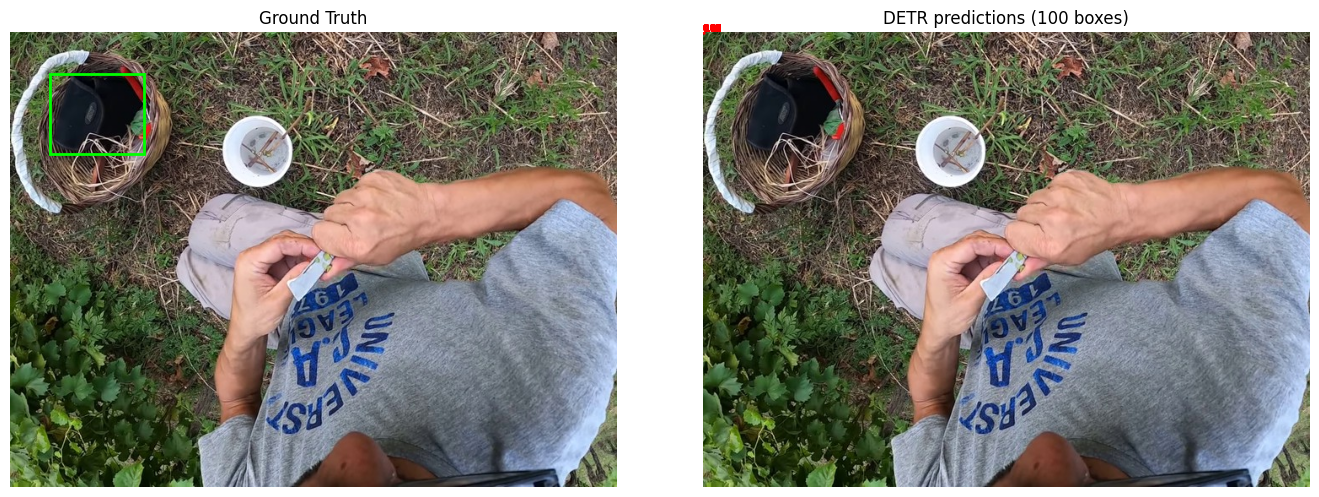

In [103]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

img_path = list(val_img_dir.glob("*.jpg"))[0]
lbl_path = val_lbl_dir / img_path.with_suffix(".txt").name

img  = Image.open(img_path).convert("RGB")
w, h = img.size

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ground truth
axes[0].imshow(img)
if lbl_path.exists():
    for line in lbl_path.read_text().strip().split("\n"):
        if not line.strip(): continue
        _, cx, cy, bw, bh = map(float, line.split())
        rect = patches.Rectangle(
            ((cx-bw/2)*w, (cy-bh/2)*h), bw*w, bh*h,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        axes[0].add_patch(rect)
axes[0].set_title("Ground Truth")
axes[0].axis("off")

# DETR predictions at conf=0.05
inputs  = detr_processor(images=img, return_tensors="pt").to(DEVICE)
outputs = detr_finetuned_model(**inputs)
results = detr_processor.post_process_object_detection(
    outputs, threshold=0.05,
    target_sizes=torch.tensor([[h, w]]).to(DEVICE)
)[0]

axes[1].imshow(img)
for score, box in zip(results["scores"], results["boxes"]):
    x1, y1, x2, y2 = box.tolist()
    rect = patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=1, edgecolor="red", facecolor="none"
    )
    axes[1].add_patch(rect)
    axes[1].text(x1, y1-2, f"{score:.2f}", color="red", fontsize=6)
axes[1].set_title(f"DETR predictions ({len(results['scores'])} boxes)")
axes[1].axis("off")

plt.tight_layout()
plt.show()